In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2022_E/tools/')
from datasets import temperate_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
temperate_data = temperate_dataset(1000)

In [3]:
batch_size = 5
data_loader = LoadArray(temperate_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(
    # gluon.nn.Dense(3),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'sgd',{'learning_rate':0.0000001})

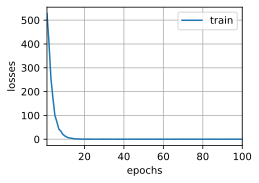

In [6]:
epochs = 100
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,100])
for epoch in range(epochs):
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
    animator.add(epoch+1, (temp,))
        
                

In [7]:
model[0].weight.data()

array([[0.32674655, 0.24087906, 0.0712734 , 0.06569625, 0.00762119]])

In [8]:
from mxnet import npx,np
npx.set_np()
feature = np.array([[87.24, 64.72, 16.43, 12.07, 1.182]])
model(feature)

array([[46.072155]])

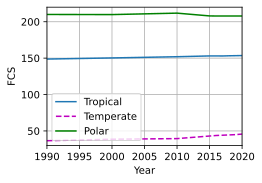

In [9]:
tropical = (148.74, 150.29, 151.96, 153.05, 153.06, 152.99, 153.25, 153.40, 153.56)
temperate = (36.58, 38.65, 39.49, 43.04, 43.75, 44.15, 44.55, 44.95, 45.72)
polar = (210.01, 209.84, 211.82, 208.01, 207.88, 207.88, 207.88, 207.88, 207.88)
years = (1990, 2000, 2010, 2015, 2016, 2017, 2018, 2019, 2020)
print(years)
# 创建 Animator 对象
animator = Animator(xlabel='Year', ylabel='FCS', legend=['Tropical', 'Temperate', 'Polar'], xlim=[1990, 2020], ylim=[30, 220])

# 添加数据并绘制图表
for year, t, temp, p in zip(years, tropical, temperate, polar):
    animator.add(year, [t, temp, p])